### Setup

In [1]:
%pip install --quiet -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Importação

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os
import shutil
import string
import random

## Criação dos valores a serem calculados os anagramas

In [3]:
def gerar_palavra(tamanho):
    return ''.join(random.choices(string.ascii_lowercase, k=tamanho))

qtd_values = [10,20,30,40, 50,60,70,80,90]

dados = {
    'palavras': [[gerar_palavra(i) for i in range(1, qtd + 1)] for qtd in qtd_values]
}

### Exibindo Amostragem

In [4]:
print(f"Palavras geradas: {dados['palavras']}")
print(f"Quantidades de dados gerados: {len(dados['palavras'])}", qtd_values)

Palavras geradas: [['m', 'it', 'yfl', 'uzcb', 'svkaf', 'mqzzzj', 'sdkgwoo', 'tbnkhfxt', 'oxlhvmjmm', 'nvjadyncur'], ['y', 'yb', 'ygq', 'eyzy', 'qusja', 'fqlgbg', 'pwwbrjw', 'phnsqkta', 'flzdogvlf', 'xlupcamxfi', 'fieqvnhpxxu', 'invkzrumcwmo', 'pxtsaycawgfpy', 'izhwzmsgccdeoc', 'bzafsugknotaayl', 'swfpktdkveqxwtoj', 'rvqngpcbbtvqjgczu', 'pjepvevzdzfdsuvdap', 'asxlmaphduimwgrmdyn', 'xcyqsyvhenikhtkekjje'], ['o', 'we', 'ykf', 'rxgu', 'niaxj', 'lwczrw', 'liofgzz', 'eijpmksk', 'hwwayazgr', 'vozueclgdx', 'dovlkoabtft', 'tiafydxhikkk', 'xljnngdcropms', 'mpfzsxiewulqxp', 'gyimjymoualxjte', 'ebvdbgjcrzzevaen', 'vqsihbkxuacuslmmn', 'flksmfsuvxxmaketxs', 'clwvfpojigobpotzxuk', 'acawftsaqpyrsfwvuiak', 'mxwmcbumjtjaxrildwtus', 'qzkseewbxetdxghmdgvnrc', 'tgfvfxyjkqspyrwdgxlttub', 'fnqtynkjfsztkgebnbypctif', 'ualxptypaetcpglcstqkrpqxw', 'witovwhakcxzxirrqurygezctc', 'vmcyibqunffmxqjlwphgxofelnr', 'qxtfwqvbrvgkwgzbrdympzroixcy', 'xojbusqongarivbkawmfeqmzspqmz', 'vqtivjtmzumkvoymragljrhntphrql'], ['z',

### Salvando amostragem em txt

In [5]:
paths = []

# Caminho base
base_path = 'files/palavras'
shutil.rmtree('files', ignore_errors=True)

os.makedirs(base_path, exist_ok=True)

for title, values in dados.items():
    for i, value in enumerate(values):
        path = f'files/{title}/{len(value)}_palavras.csv'
        paths.append(path)
        
        os.makedirs(os.path.dirname(path), exist_ok=True)
        
        # Converte as palavras em um DataFrame (uma coluna com cada palavra em uma linha)
        df = pd.DataFrame(value, columns=["Palavra"])
        # Salva o DataFrame no arquivo CSV
        df.to_csv(path, index=False, header=False)
# Exibe os arquivos gerados
        
print(f'Arquivos salvos em {os.path.abspath("files")}')

Arquivos salvos em /home/jonascgn/Trabalhos/Trabalho-2---PAA/files


## Recursivo

In [6]:
%%capture anagrama_results_recursive
for path in paths:
    tamanho = path.split('/')[-1].split('.')[0].split('_')[0]
    args_copy = f"FILE_PATH={path} QTD_WORD={tamanho} QTD_TEST=10 SHOW_RESULT=0"
    !make -B anagrama_recursivo {args_copy}

In [7]:
anagrama_results_recursive.show()

Tempo:0.000005s Memoria:0.49KB Qtd:10
Tempo:0.000008s Memoria:0.85KB Qtd:20
Tempo:0.000012s Memoria:1.31KB Qtd:30
Tempo:0.000017s Memoria:1.62KB Qtd:40
Tempo:0.000020s Memoria:2.16KB Qtd:50
Tempo:0.000025s Memoria:2.64KB Qtd:60
Tempo:0.000030s Memoria:3.03KB Qtd:70
Tempo:0.000035s Memoria:3.42KB Qtd:80
Tempo:0.000038s Memoria:4.00KB Qtd:90


## Dinamico

In [8]:
%%capture anagrama_results_dinamico
for path in paths:
    tamanho = path.split('/')[-1].split('.')[0].split('_')[0]
    args_copy = f"FILE_PATH={path} QTD_WORD={tamanho} QTD_TEST=10 SHOW_RESULT=0"
    !make -B anagrama_dinamico {args_copy}

In [9]:
anagrama_results_dinamico.show()


Tempo:0.000651s Memoria:1.34KB Qtd:10
Tempo:0.000652s Memoria:1.50KB Qtd:20
Tempo:0.000709s Memoria:1.68KB Qtd:30
Tempo:0.000699s Memoria:1.88KB Qtd:40
Tempo:0.000698s Memoria:2.10KB Qtd:50
Tempo:0.000685s Memoria:2.35KB Qtd:60
Tempo:0.000688s Memoria:2.62KB Qtd:70
Tempo:0.000698s Memoria:2.92KB Qtd:80
Tempo:0.000703s Memoria:3.24KB Qtd:90


# Graficos

In [10]:
def formatar_dados(results):
  # Extrai os dados do resultado
  data = []
  lines = results.stdout.split('\n')
  
  for line in lines:
      if line.startswith('Tempo:'):
          parts = line.split()
          tempo = parts[0].split(':')[1][:-1]
          memoria = parts[1].split(':')[1][:-2]
          qtd = parts[2].split(':')[1]
          data.append((tempo, memoria, qtd))
  return pd.DataFrame(data, columns=["Tempo", "Memoria", "Qtd"])


In [11]:
print("\nAnagramas recursivo")
formatado_recusivo = formatar_dados(anagrama_results_recursive)
formatado_recusivo


Anagramas recursivo


,Tempo,Memoria,Qtd
0,0.000005,0.49,10
1,0.000008,0.85,20
2,0.000012,1.31,30
3,0.000017,1.62,40
4,0.000020,2.16,50
5,0.000025,2.64,60
6,0.000030,3.03,70
7,0.000035,3.42,80
8,0.000038,4.00,90


In [12]:
print("\nAnagramas recursivo")
formatado_dinamico = formatar_dados(anagrama_results_dinamico)
formatado_dinamico


Anagramas recursivo


,Tempo,Memoria,Qtd
0,0.000651,1.34,10
1,0.000652,1.50,20
2,0.000709,1.68,30
3,0.000699,1.88,40
4,0.000698,2.10,50
5,0.000685,2.35,60
6,0.000688,2.62,70
7,0.000698,2.92,80
8,0.000703,3.24,90


In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def gerar_graficos(data):
    # Converte os dados de tempo e memória para float
    data["Tempo"] = data["Tempo"].astype(float)
    data["Memoria"] = data["Memoria"].astype(float)
    data["Qtd"] = data["Qtd"].astype(int)

    # Configura os gráficos lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Configura o formatador para evitar notação científica nos eixos
    formatter = ScalarFormatter()
    formatter.set_scientific(False)
    formatter.set_useOffset(False)

    # Gráfico de Tempo
    axes[0].plot(data["Qtd"], data["Tempo"], marker='o', label="Tempo")
    axes[0].set_title("Tempo de Execução")
    axes[0].set_xlabel("Quantidade de Palavras")
    axes[0].set_ylabel("Tempo (s)")
    axes[0].grid(True)
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(formatter)

    # Gráfico de Memória
    axes[1].plot(data["Qtd"], data["Memoria"], marker='o', color='orange', label="Memória")
    axes[1].set_title("Uso de Memória")
    axes[1].set_xlabel("Quantidade de Palavras")
    axes[1].set_ylabel("Memória (KB)")
    axes[1].grid(True)
    axes[1].legend()
    axes[1].yaxis.set_major_formatter(formatter)

    # Exibe os valores reais nos gráficos formatados
    for i, row in data.iterrows():
        axes[0].text(row["Qtd"], row["Tempo"], f"{row['Tempo']:.6f}", fontsize=9, ha='right')  # Formata para 4 casas decimais
        axes[1].text(row["Qtd"], row["Memoria"], f"{row['Memoria']:.2f}", fontsize=9, ha='right')  # Formata para 2 casas decimais

    plt.tight_layout()
    plt.show()


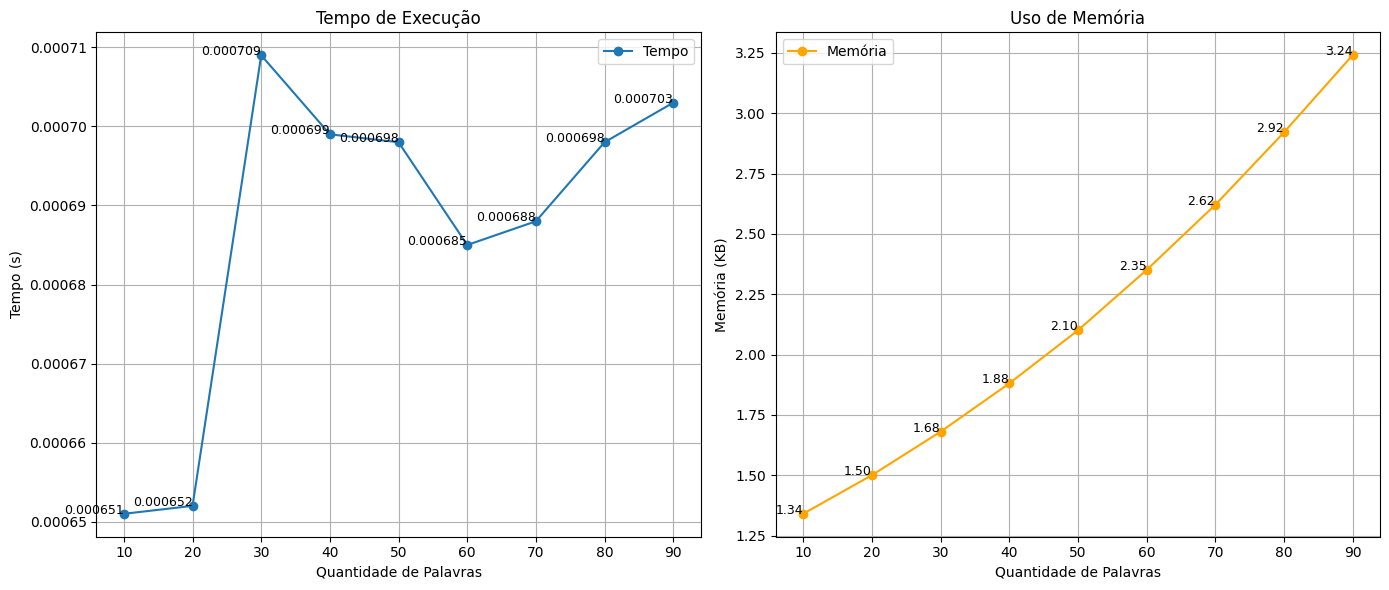

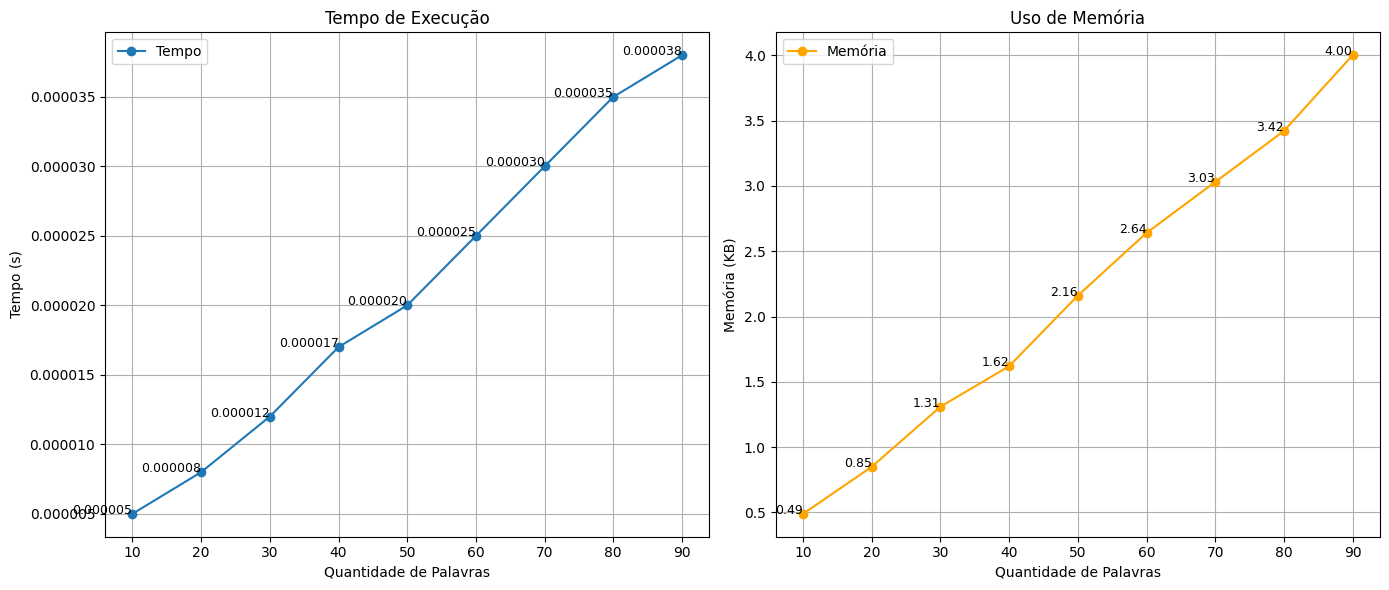

In [20]:
gerar_graficos(formatar_dados(anagrama_results_dinamico))
gerar_graficos(formatar_dados(anagrama_results_recursive))